In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
PAD, SOS, EOS = "<PAD>", "<SOS>", "<EOS>"

In [15]:
df = pd.read_csv(
    "/content/drive/MyDrive/chembl_36_chemreps.txt",
    sep="\t", usecols=["canonical_smiles"], nrows=20000
)
df = df.dropna().drop_duplicates()
df = df[df["canonical_smiles"].str.len() < 100]
df = df.sample(5000, random_state=42)
smiles_list = df["canonical_smiles"].tolist()
print("Loaded molecules:", len(smiles_list))

Loaded molecules: 5000


In [16]:
all_text = "".join(smiles_list)
chars = sorted(set(all_text))

# Reserve 0 for PAD, then SOS=1, EOS=2, real chars start at 3
char_to_idx = {PAD: 0, SOS: 1, EOS: 2}
char_to_idx.update({ch: i + 3 for i, ch in enumerate(chars)})
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size = len(char_to_idx)
print("Vocab size:", vocab_size)

Vocab size: 44


In [17]:
class SmilesDataset(Dataset):
    def __init__(self, smiles_list, char_to_idx):
        self.data = smiles_list
        self.c2i = char_to_idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        encoded = [self.c2i[ch] for ch in self.data[idx]]
        input_seq  = torch.tensor([self.c2i[SOS]] + encoded,       dtype=torch.long)
        target_seq = torch.tensor(encoded         + [self.c2i[EOS]], dtype=torch.long)
        return input_seq, target_seq


def collate_fn(batch):
    inputs, targets = zip(*batch)
    inputs_p  = nn.utils.rnn.pad_sequence(inputs,  batch_first=True, padding_value=0)
    targets_p = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=0)
    return inputs_p, targets_p


dataset = SmilesDataset(smiles_list, char_to_idx)

val_size  = int(0.1 * len(dataset))
train_ds, val_ds = torch.utils.data.random_split(
    dataset, [len(dataset) - val_size, val_size], generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_fn)

In [18]:
class SmilesLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_size=512, num_layers=3, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.dropout(self.embedding(x))
        x, hidden = self.lstm(x, hidden)
        x = self.fc(self.dropout(x))
        return x, hidden


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SmilesLSTM(vocab_size).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 5,813,292


In [19]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

num_epochs  = 30
best_val    = float("inf")
best_path   = "best_smiles_lstm.pt"

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss, correct, total_tokens = 0.0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        logits, _ = model(inputs)
        loss = criterion(logits.view(-1, vocab_size), targets.view(-1))
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        preds  = logits.argmax(-1)
        mask   = targets != 0
        correct      += (preds[mask] == targets[mask]).sum().item()
        total_tokens += mask.sum().item()

    avg_train = train_loss / len(train_loader)
    acc       = correct / total_tokens if total_tokens else 0

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            val_loss += criterion(logits.view(-1, vocab_size), targets.view(-1)).item()
    avg_val = val_loss / len(val_loader)

    scheduler.step(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        torch.save(model.state_dict(), best_path)

    print(
        f"Epoch [{epoch:3d}/{num_epochs}] "
        f"train_loss={avg_train:.4f}  val_loss={avg_val:.4f}  acc={acc:.4f}"
    )

model.load_state_dict(torch.load(best_path, map_location=device))

Epoch [  1/30] train_loss=2.2367  val_loss=1.6591  acc=0.3751
Epoch [  2/30] train_loss=1.4953  val_loss=1.2994  acc=0.5320
Epoch [  3/30] train_loss=1.2961  val_loss=1.1603  acc=0.5890
Epoch [  4/30] train_loss=1.1869  val_loss=1.0762  acc=0.6220
Epoch [  5/30] train_loss=1.1176  val_loss=1.0190  acc=0.6400
Epoch [  6/30] train_loss=1.0631  val_loss=0.9748  acc=0.6559
Epoch [  7/30] train_loss=1.0208  val_loss=0.9376  acc=0.6682
Epoch [  8/30] train_loss=0.9874  val_loss=0.9112  acc=0.6777
Epoch [  9/30] train_loss=0.9578  val_loss=0.8902  acc=0.6853
Epoch [ 10/30] train_loss=0.9365  val_loss=0.8757  acc=0.6917
Epoch [ 11/30] train_loss=0.9134  val_loss=0.8545  acc=0.6989
Epoch [ 12/30] train_loss=0.8932  val_loss=0.8335  acc=0.7042
Epoch [ 13/30] train_loss=0.8768  val_loss=0.8224  acc=0.7087
Epoch [ 14/30] train_loss=0.8604  val_loss=0.8075  acc=0.7157
Epoch [ 15/30] train_loss=0.8468  val_loss=0.7984  acc=0.7176
Epoch [ 16/30] train_loss=0.8307  val_loss=0.7849  acc=0.7229
Epoch [ 

<All keys matched successfully>

In [20]:
def generate(
    model,
    char_to_idx,
    idx_to_char,
    start_char="C",
    max_length=100,
    temperature=1.0,
    top_p=0.9,
):
    model.eval()
    generated = start_char
    input_seq = torch.tensor([[char_to_idx[SOS], char_to_idx[start_char]]], dtype=torch.long).to(device)

    with torch.no_grad():
        _, hidden = model(input_seq)

        for _ in range(max_length):
            x = torch.tensor([[char_to_idx[generated[-1]]]], dtype=torch.long).to(device)
            logits, hidden = model(x, hidden)

            logits = logits[0, -1] / temperature
            probs     = torch.softmax(logits, dim=-1)
            sorted_p, sorted_idx = torch.sort(probs, descending=True)
            cumulative = torch.cumsum(sorted_p, dim=0)

            cutoff    = (cumulative - sorted_p) > top_p
            sorted_p[cutoff] = 0.0
            sorted_p /= sorted_p.sum()

            next_idx  = sorted_idx[torch.multinomial(sorted_p, 1)].item()
            next_char = idx_to_char[next_idx]

            if next_char in (EOS, PAD):
                break
            generated += next_char

    return generated

In [21]:
try:
    from rdkit import Chem
    def is_valid(smiles: str) -> bool:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
except ImportError:
    def is_valid(smiles: str) -> bool:
        return True

n_samples   = 50
valid_count = 0
for _ in range(n_samples):
    smi = generate(model, char_to_idx, idx_to_char, temperature=1.0, top_p=0.9)
    if is_valid(smi):
        valid_count += 1
        print("✓", smi)
    else:
        print("✗", smi)

print(f"\nValidity rate: {valid_count}/{n_samples} = {valid_count/n_samples:.0%}")

✓ CCCCN1CCC(C2CCN(c3ccccc3)CC2)CC1
✓ C(=O)Nc1nc(Cl)cc2c1CNCC2
✓ CCC(=O)Nc1cc(OCc2ccc3cc(F)ccc3n2)cc1OC
✓ CC(c1cccc(N)c1)c1nc(C(=O)O)cn1Cc1ccc(Cl)c(Cl)c1
✓ CCCCCN(C(=O)[C@@H]1CCC[C@@H]1C(=O)N[C@@H](CC(C)C)C(=O)O)C(=O)NCCc1ccccc1
✓ C1=NN(C(=O)Nc2ccccc2)c2ccccc2C1=O
✓ CCN(C(=O)c1cc(C(F)(F)F)cc(NS(C)(=O)=O)c1)C(C)C
✓ C1(c2ccccc2)C(C)(C)N1
✓ C(=O)NC1CCC2(CC1)CCCCC2
✓ COC(=O)c1ccc(Cl)cc1CSCc1ccc2nc(O)nc(O)c2c1
✓ CCNC(=O)c1ccc(O)c(Cl)c1C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O)N[C@@H](Cc1ccccc1)NC(=O)[C@H](N)CC(=O)N[C@@H](C
✓ CN(CCC)CC(c1ccc(C(C)C)cc1)C(=O)NC1CCCCCC1
✓ C(=O)Nc1ccc(CNc2nccc3c(N4CCN(C)CC5)ccc3c2=O)cc1
✓ C1(c2ccccc2)=C(c2ccccc2)N(CCCCCCN2CCN(Cc3ccccc3)CC2)S(=O)(=O)C1
✓ CCN(CC)C(=O)c1cc(C(=O)Nc2ccccc2)c(C(=O)Nc2ccccc2)cc1
✓ CCCOc1cccc(C(=O)Nc2ccc(C)c(NS(=O)(=O)CC(C)(C)C)c2)c1
✓ C(=O)c1ccc(OCc2ccc(OCc3ccc4ccc(OCC(F)(F)F)cc3)cc2)c(-c2ccccc2)c(C(C)(C)C)c1
✓ C(C)(C)/N=C(/NCc1ccc(-c2ccccc2)cc1)c1ccc(Cl)cc1
✓ C(C)Oc1cccc(C(C)C)c1CC(=O)NCCNCC(O)c1ccc(Cl)cc1
✓ C(C)Oc1cccc(CCN2CCN(C(=O)Cn3cc(Cc4cccc

In [25]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 18.7 MB/s eta 0:00:00


Generating 100 molecules...



[16:23:20] Can't kekulize mol.  Unkekulized atoms: 1 2 3 11 12 13 14 23 24
[16:23:20] SMILES Parse Error: unclosed ring for input: 'c1Oc1ccc2nc(Sc3ccc(S(=O)(=O)O)cc3)cnc2n1'
[16:23:20] Can't kekulize mol.  Unkekulized atoms: 0 3 4 5 6 7 8
[16:23:20] SMILES Parse Error: ring closure 1 duplicates bond between atom 9 and atom 10 for input: 'c1C(=O)Oc1ccccc1C1=C(CC(C)(C)C)C(=O)O'
[16:23:20] Can't kekulize mol.  Unkekulized atoms: 0 3 4 5 13 14 18
[16:23:21] Can't kekulize mol.  Unkekulized atoms: 3 4 5 16 17 18 19
[16:23:21] SMILES Parse Error: unclosed ring for input: 'c1OCCCN1CCC(c2noc3cc(F)ccc23)CC1'
[16:23:21] Can't kekulize mol.  Unkekulized atoms: 0 1 2 14 15 16 18 19 20
[16:23:21] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 18 19 20
[16:23:21] SMILES Parse Error: unclosed ring for input: 'c1NC(=O)c1cc(S(N)(=O)=O)c(N)cc1Cl'
[16:23:21] Can't kekulize mol.  Unkekulized atoms: 0 3 4 5 16 17
[16:23:21] SMILES Parse Error: extra close parentheses while parsing: C(C)(C)Nc1nc(SC

Results: 48 valid  |  52 invalid  |  0 duplicates removed
Validity rate : 48%
Uniqueness    : 100%

── Metrics (valid + unique molecules)
  QED    mean=0.586  max=0.939
  MW     mean=320.8   range=[146, 673]
  LogP   mean=2.60
  Ro5 pass rate: 37/48 = 77%
Top 10 molecules by QED score:
#    QED     MW       LogP    Ro5    SMILES
----------------------------------------------------------------------
1    0.939   281.31   2.37    ✓      COc1ccc(C2=C(C(N)=O)COc3ccccc32)cc1
2    0.81    302.25   3.85    ✓      OCCNCC1CCC(c2ccc(Cl)cc2Cl)CC1
3    0.805   284.16   5.31    ✗      CC(Nc1cc(Cl)cc(Cl)c1)c1ccc(F)cc1
4    0.8     247.29   2.09    ✓      O=C(CCCc1ccccc1)ON1CCCC1=O
5    0.783   338.45   3.71    ✓      NC(=O)c1ccc(-c2ccc(OCCCN3CCCCC3)cc2)cc1
6    0.783   331.8    3.51    ✓      CC(C)Nc1ccc(Cl)cc1C(=O)Nc1ccc(C(N)=O)cc1
7    0.778   265.35   1.95    ✓      Cc1cc(C(CCO)C(N)=O)c(O)c(C(C)(C)C)c1
8    0.767   249.31   3.93    ✓      CC1OC(c2ccccc2)Cc2ccc(C#N)cc21
9    0.755   315.33   0.11 

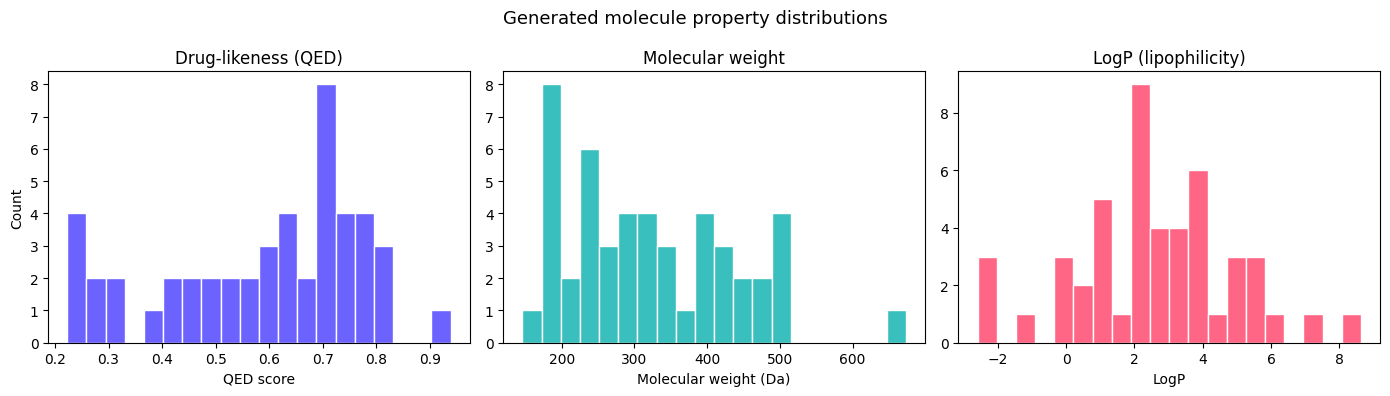

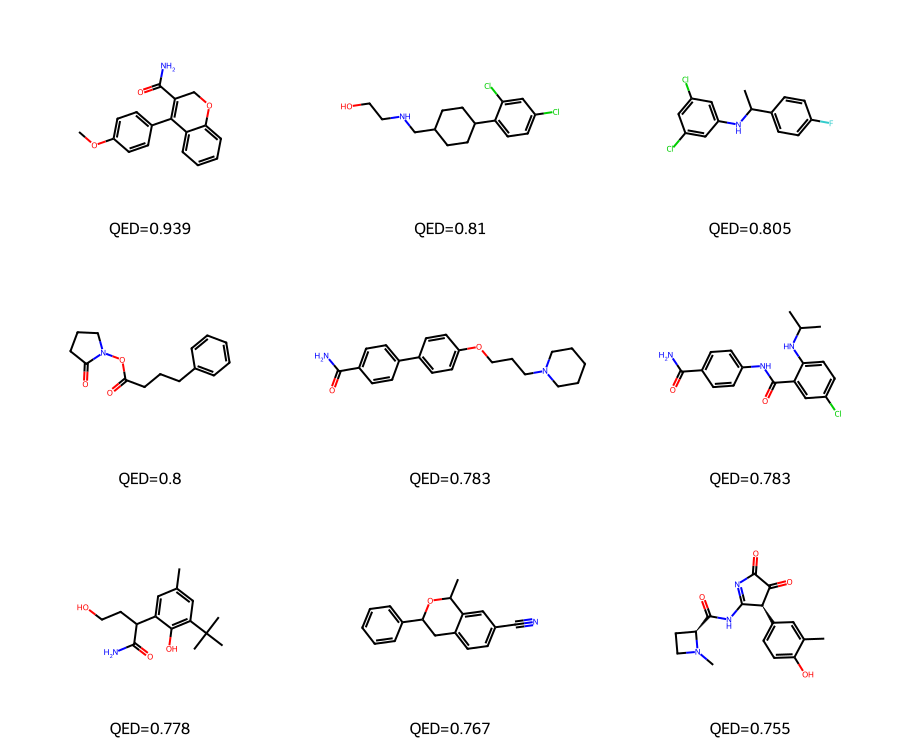

In [26]:
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, Draw
from rdkit.Chem import rdMolDescriptors
import matplotlib.pyplot as plt
from IPython.display import display

def generate(
    model,
    char_to_idx,
    idx_to_char,
    start_char="C",
    max_length=100,
    temperature=1.0,
    top_p=0.9,
):
    model.eval()
    generated = start_char
    input_seq = torch.tensor(
        [[char_to_idx[SOS], char_to_idx[start_char]]], dtype=torch.long
    ).to(device)

    with torch.no_grad():
        _, hidden = model(input_seq)

        for _ in range(max_length):
            x = torch.tensor(
                [[char_to_idx[generated[-1]]]], dtype=torch.long
            ).to(device)
            logits, hidden = model(x, hidden)

            logits = logits[0, -1] / temperature
            probs  = torch.softmax(logits, dim=-1)

            sorted_p, sorted_idx = torch.sort(probs, descending=True)
            cumulative = torch.cumsum(sorted_p, dim=0)
            cutoff     = (cumulative - sorted_p) > top_p
            sorted_p[cutoff] = 0.0
            sorted_p /= sorted_p.sum()

            next_idx  = sorted_idx[torch.multinomial(sorted_p, 1)].item()
            next_char = idx_to_char[next_idx]

            if next_char in (EOS, PAD):
                break
            generated += next_char

    return generated

def lipinski(mol):
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    passes = (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)
    return {"MW": round(mw, 2), "LogP": round(logp, 2),
            "HBD": hbd, "HBA": hba, "Ro5": passes}


N = 100
start_chars = ["C", "N", "O", "c", "n"]

results = []
invalid = 0

print(f"Generating {N} molecules...\n")

for i in range(N):
    start = start_chars[i % len(start_chars)]

    if start not in char_to_idx:
        invalid += 1
        continue

    smi = generate(
        model, char_to_idx, idx_to_char,
        start_char=start,
        temperature=1.0,
        top_p=0.9,
    )

    mol = Chem.MolFromSmiles(smi)

    if mol is None:
        invalid += 1
        continue
    canon = Chem.MolToSmiles(mol)
    lip   = lipinski(mol)
    qed   = round(QED.qed(mol), 3)

    results.append({
        "smiles": canon,
        "mol":    mol,
        "QED":    qed,
        **lip,
    })

seen   = set()
unique = []
for r in results:
    if r["smiles"] not in seen:
        seen.add(r["smiles"])
        unique.append(r)

valid_count = len(unique)
print(f"Results: {valid_count} valid  |  {invalid} invalid  |  {N - valid_count - invalid} duplicates removed")
print(f"Validity rate : {valid_count / N:.0%}")
print(f"Uniqueness    : {valid_count / max(len(results), 1):.0%}\n")

if unique:
    import statistics
    qeds  = [r["QED"]  for r in unique]
    mws   = [r["MW"]   for r in unique]
    logps = [r["LogP"] for r in unique]
    ro5   = sum(1 for r in unique if r["Ro5"])

    print("── Metrics (valid + unique molecules)")
    print(f"  QED    mean={statistics.mean(qeds):.3f}  max={max(qeds):.3f}")
    print(f"  MW     mean={statistics.mean(mws):.1f}   range=[{min(mws):.0f}, {max(mws):.0f}]")
    print(f"  LogP   mean={statistics.mean(logps):.2f}")
    print(f"  Ro5 pass rate: {ro5}/{valid_count} = {ro5/valid_count:.0%}")

top10 = sorted(unique, key=lambda x: x["QED"], reverse=True)[:10]

print("Top 10 molecules by QED score:")
print(f"{'#':<4} {'QED':<7} {'MW':<8} {'LogP':<7} {'Ro5':<6} SMILES")
print("-" * 70)
for i, r in enumerate(top10, 1):
    ro5_str = "✓" if r["Ro5"] else "✗"
    print(f"{i:<4} {r['QED']:<7} {r['MW']:<8} {r['LogP']:<7} {ro5_str:<6} {r['smiles']}")

if unique:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle("Generated molecule property distributions", fontsize=13)

    axes[0].hist(qeds,  bins=20, color="#6C63FF", edgecolor="white")
    axes[0].set_xlabel("QED score"); axes[0].set_ylabel("Count")
    axes[0].set_title("Drug-likeness (QED)")

    axes[1].hist(mws,   bins=20, color="#3ABFBF", edgecolor="white")
    axes[1].set_xlabel("Molecular weight (Da)")
    axes[1].set_title("Molecular weight")

    axes[2].hist(logps, bins=20, color="#FF6584", edgecolor="white")
    axes[2].set_xlabel("LogP")
    axes[2].set_title("LogP (lipophilicity)")

    plt.tight_layout()
    plt.show()

if len(top10) >= 1:
    draw_mols = [r["mol"]    for r in top10[:9]]
    legends   = [f"QED={r['QED']}" for r in top10[:9]]

    img = Draw.MolsToGridImage(
        draw_mols,
        molsPerRow=3,
        subImgSize=(300, 250),
        legends=legends,
    )
    display(img)